In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/raw/cs-training.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
target = "SeriousDlqin2yrs"

default_rate = df[target].mean()
print(f"Overall Default Rate: {default_rate:.2%}")

Overall Default Rate: 6.68%


In [8]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"]
)

age_default = df.groupby("age_group")[target].mean().sort_index()

age_default

age_group
<25      0.111662
25-35    0.111225
35-45    0.088132
45-55    0.075933
55-65    0.045830
65+      0.024103
Name: SeriousDlqin2yrs, dtype: float64

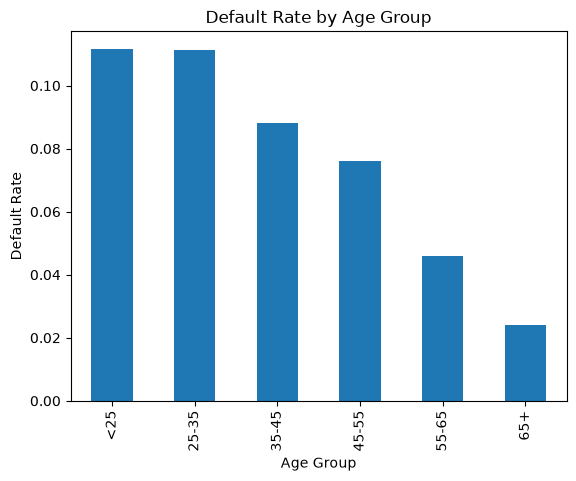

In [10]:
age_default.plot(kind="bar")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.show()

In [11]:
past_due_col = "NumberOfTime30-59DaysPastDueNotWorse"

past_due_default = df.groupby(past_due_col)[target].mean()

past_due_default.head(10)

NumberOfTime30-59DaysPastDueNotWorse
0    0.040002
1    0.150253
2    0.265115
3    0.352338
4    0.425703
5    0.450292
6    0.528571
7    0.518519
8    0.320000
9    0.333333
Name: SeriousDlqin2yrs, dtype: float64

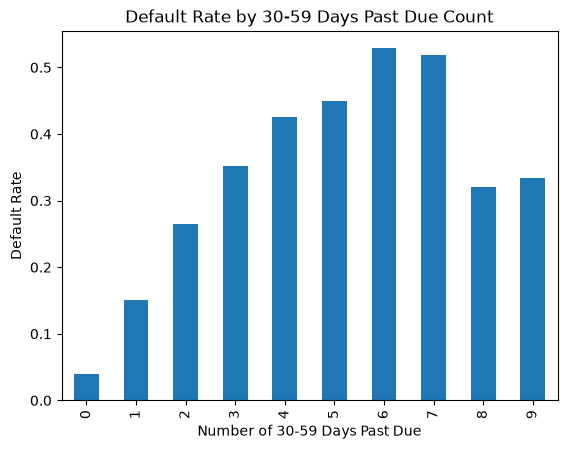

In [13]:
past_due_default.head(10).plot(kind="bar")

plt.title("Default Rate by 30-59 Days Past Due Count")
plt.xlabel("Number of 30-59 Days Past Due")
plt.ylabel("Default Rate")
plt.show()

In [15]:
late_90_col = "NumberOfTimes90DaysLate"

late_90_default = df.groupby(late_90_col)[target].mean()

late_90_default.head(10)


NumberOfTimes90DaysLate
0    0.046265
1    0.336639
2    0.499035
3    0.577211
4    0.670103
5    0.633588
6    0.600000
7    0.815789
8    0.714286
9    0.736842
Name: SeriousDlqin2yrs, dtype: float64

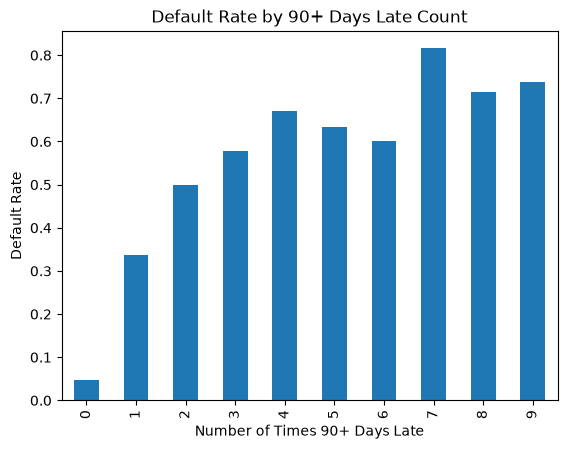

In [17]:
late_90_default.head(10).plot(kind="bar")

plt.title("Default Rate by 90+ Days Late Count")
plt.xlabel("Number of Times 90+ Days Late")
plt.ylabel("Default Rate")
plt.show()

In [19]:
df["utilization_bucket"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-0.01, 0.1, 0.3, 0.6, 1.0, 10],
    labels=["0-10%", "10-30%", "30-60%", "60-100%", "100%+"]
)

util_default = df.groupby("utilization_bucket")[target].mean()

util_default

utilization_bucket
0-10%      0.018104
10-30%     0.031428
30-60%     0.066798
60-100%    0.165027
100%+      0.396104
Name: SeriousDlqin2yrs, dtype: float64

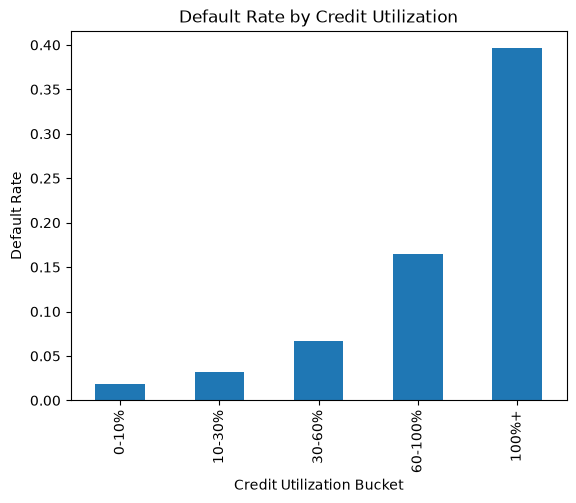

In [21]:
util_default.plot(kind="bar")

plt.title("Default Rate by Credit Utilization")
plt.xlabel("Credit Utilization Bucket")
plt.ylabel("Default Rate")
plt.show()

In [23]:
df["debt_ratio_bucket"] = pd.cut(
    df["DebtRatio"],
    bins=[-0.01, 0.2, 0.5, 1, 2, 10],
    labels=["0-20%", "20-50%", "50-100%", "100-200%", "200%+"]
)

debt_default = df.groupby("debt_ratio_bucket")[target].mean()

debt_default

debt_ratio_bucket
0-20%       0.061127
20-50%      0.059706
50-100%     0.098322
100-200%    0.131720
200%+       0.065959
Name: SeriousDlqin2yrs, dtype: float64

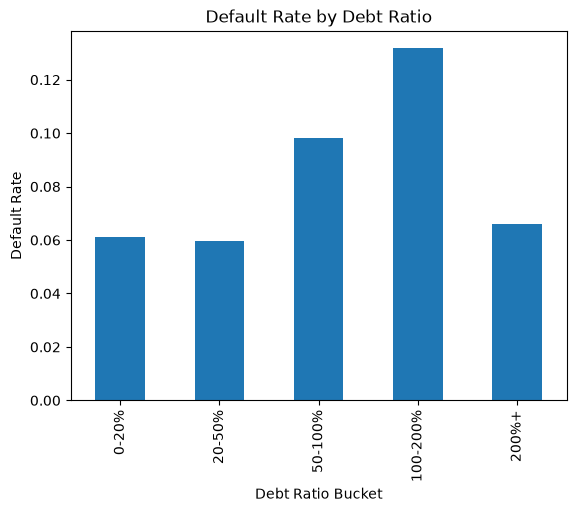

In [25]:
debt_default.plot(kind="bar")

plt.title("Default Rate by Debt Ratio")
plt.xlabel("Debt Ratio Bucket")
plt.ylabel("Default Rate")
plt.show()

In [27]:
correlation_with_default = df.corr(numeric_only=True)[target].sort_values(ascending=False)

correlation_with_default

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

## EDA Business Observations

The exploratory analysis shows how borrower characteristics are associated with default risk.

Late payment variables such as `NumberOfTimes90DaysLate` and `NumberOfTime30-59DaysPastDueNotWorse` are expected to be strong risk indicators because they directly reflect repayment behaviour.

Credit utilization and debt burden are also important because they indicate how much pressure the borrower may be under financially.

These variables will be important inputs for the Probability of Default model in the next stage of the project.